# 03 Index Construction

This notebook builds the **AI Literacy Gap Index** from the pillar feature table produced in `02_EDA.ipynb`.

A higher index score means a larger AI literacy gap (= higher risk).

---

## Structure

### Part 1 — Data preparation
- Step 1: Load pillar feature table and inspect
- Step 2: Min-max normalisation [0, 1] per pillar
- Step 3: Direction alignment — invert P1 and P4 (higher = better → higher = more risk)

### Part 2 — Index construction (two variants)
- Step 4 — Variant 1 · **Baseline:** Equal weights (1/6 per pillar) — OECD standard
- Step 5 — Variant 2 · **PCA weights:** Data-driven — weights derived from variance structure via Principal Component Analysis (PC1-only and variance-weighted all-PC)

### Part 3 — Validation and output
- Step 6: Ranking comparison — Baseline vs. PCA robustness check
- Step 7: Select final index and save to `data/processed/ai_literacy_gap_index.csv`

---

> **Clustering** is handled separately in `04_clustering.ipynb`, which reads the final index CSV as its input.

In [183]:
from pathlib import Path
import pandas as pd
import numpy as np

# -----------------------------
# Project paths
# -----------------------------
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

print("Project directory:", PROJECT_DIR)
print("Processed data directory:", PROCESSED_DIR)

# -----------------------------
# Pillar definitions (used throughout this notebook)
# -----------------------------
PILLARS = {
    'P1': 'digital_skills_pct',
    'P2': 'poverty_social_exclusion_rate',
    'P3': 'low_education_pct',
    'P4': 'lifelong_learning_pct',
    'P5': 'unemployment_rate_low_edu_pct',
    'P6': 'share_ge65_pct',
}
INVERT = {'P1', 'P4'}  # higher raw value = better → invert so higher = more risk

Project directory: /Users/joshuakehrer/code/JoshK00/ai-literacy-gap-index/AI-Literacy-Gap-Index
Processed data directory: /Users/joshuakehrer/code/JoshK00/ai-literacy-gap-index/AI-Literacy-Gap-Index/data/processed


## Step 1: Load pillar feature table

Load `pillar_feature_table.csv` produced by `02_EDA.ipynb`. Inspect shape, columns, missing values, and value ranges before any transformation.

In [184]:
# -----------------------------
# Load feature table
# -----------------------------
feature_table_path = PROCESSED_DIR / "pillar_feature_table.csv"

if not feature_table_path.exists():
    raise FileNotFoundError(
        f"Feature table not found at {feature_table_path}. "
        "Please run 02_EDA.ipynb first."
    )

feature_table = pd.read_csv(feature_table_path)

print(f"Shape: {feature_table.shape}")
print(f"\nColumns: {list(feature_table.columns)}")
print(f"\nMissing values per column:")
print(feature_table.isna().sum().to_string())
print()
display(feature_table)

Shape: (87, 8)

Columns: ['geo', 'digital_skills_pct', 'poverty_social_exclusion_rate', 'low_education_pct', 'lifelong_learning_pct', 'unemployment_rate_low_edu_pct', 'unemployment_flag', 'share_ge65_pct']

Missing values per column:
geo                               0
digital_skills_pct                0
poverty_social_exclusion_rate     0
low_education_pct                 0
lifelong_learning_pct             0
unemployment_rate_low_edu_pct     7
unemployment_flag                50
share_ge65_pct                    0



,geo,digital_skills_pct,poverty_social_exclusion_rate,low_education_pct,lifelong_learning_pct,unemployment_rate_low_edu_pct,unemployment_flag,share_ge65_pct
0,AT1,70.65,21.399283,14.3,17.4,15.6,NaN,19.30
1,AT2,69.50,19.909530,11.1,15.7,12.7,NaN,22.71
2,AT3,68.84,14.958880,13.0,14.7,9.7,NaN,19.96
3,BE1,65.19,33.600000,18.0,23.5,25.4,NaN,12.99
4,BE2,61.20,11.452742,12.4,18.8,11.2,NaN,21.67
...,...,...,...,...,...,...,...,...
82,SE1,70.67,18.951973,10.5,40.3,28.0,NaN,18.83
83,SE2,70.54,18.456644,11.6,37.5,26.5,NaN,21.19
84,SE3,66.93,18.261679,10.4,34.5,27.5,NaN,24.77
85,SI0,46.50,15.504281,10.7,22.8,8.0,NaN,22.14


### Column legend

The table below describes each column in the feature table: which pillar it belongs to, its Eurostat source, what the numeric value measures, and how it will be treated during index construction. The `index_direction` column is key — P1 and P4 are "better when higher" and must be inverted before aggregation so that all pillars point in the same direction (higher = more risk).

In [185]:
# -----------------------------
# Column legend
# -----------------------------
legend = pd.DataFrame([
    {"column": "geo",                            "pillar": "—",  "source": "—",                 "unit": "NUTS-1 region code (e.g. DE1, FR1)",                                                                      "higher_means": "—",       "index_direction": "—"},
    {"column": "digital_skills_pct",             "pillar": "P1", "source": "isoc_r_dskl_i",    "unit": "% of individuals with basic or above-basic digital skills (indicator: I_DSK2_BAB, denominator: PC_IND)",   "higher_means": "better",  "index_direction": "invert → 1 − norm"},
    {"column": "poverty_social_exclusion_rate",  "pillar": "P2", "source": "tgs00107",          "unit": "% of population at risk of poverty or social exclusion (AROPE)",                                           "higher_means": "worse",   "index_direction": "direct"},
    {"column": "low_education_pct",              "pillar": "P3", "source": "edat_lfse_04",      "unit": "% of population aged 25–64 with at most lower secondary education (ED0-2)",                               "higher_means": "worse",   "index_direction": "direct"},
    {"column": "lifelong_learning_pct",          "pillar": "P4", "source": "trng_lfse_04",      "unit": "% of population aged 25–64 who participated in education or training in the last 4 weeks",                "higher_means": "better",  "index_direction": "invert → 1 − norm"},
    {"column": "unemployment_rate_low_edu_pct",  "pillar": "P5", "source": "lfst_r_lfu3rt",     "unit": "Unemployment rate (%) among low-educated population (ED0-2, aged 15–74)",                                 "higher_means": "worse",   "index_direction": "direct"},
    {"column": "share_ge65_pct",                 "pillar": "P6", "source": "demo_r_pjanaggr3",  "unit": "% of population aged 65 and above",                                                                        "higher_means": "worse",   "index_direction": "direct"},
    {"column": "unemployment_flag",              "pillar": "—",  "source": "lfst_r_lfu3rt",     "unit": "Eurostat quality flag for P5 value (u = unreliable sample, d = definition deviation); NaN = no flag",     "higher_means": "—",       "index_direction": "—"},
])

display(
    legend.style.set_properties(subset=["unit"], **{"min-width": "480px", "white-space": "normal"})
)

,column,pillar,source,unit,higher_means,index_direction
0,geo,—,—,"NUTS-1 region code (e.g. DE1, FR1)",—,—
1,digital_skills_pct,P1,isoc_r_dskl_i,"% of individuals with basic or above-basic digital skills (indicator: I_DSK2_BAB, denominator: PC_IND)",better,invert → 1 − norm
2,poverty_social_exclusion_rate,P2,tgs00107,% of population at risk of poverty or social exclusion (AROPE),worse,direct
3,low_education_pct,P3,edat_lfse_04,% of population aged 25–64 with at most lower secondary education (ED0-2),worse,direct
4,lifelong_learning_pct,P4,trng_lfse_04,% of population aged 25–64 who participated in education or training in the last 4 weeks,better,invert → 1 − norm
5,unemployment_rate_low_edu_pct,P5,lfst_r_lfu3rt,"Unemployment rate (%) among low-educated population (ED0-2, aged 15–74)",worse,direct
6,share_ge65_pct,P6,demo_r_pjanaggr3,% of population aged 65 and above,worse,direct
7,unemployment_flag,—,lfst_r_lfu3rt,"Eurostat quality flag for P5 value (u = unreliable sample, d = definition deviation); NaN = no flag",—,—


### Pillar definitions — detailed view

How each indicator is actually measured in the source survey.

In [186]:
# -----------------------------
# Pillar definitions — detailed view
# -----------------------------
definitions = pd.DataFrame([
    {
        "pillar": "P1",
        "column": "digital_skills_pct",
        "survey": "EU Survey on ICT usage in households and by individuals (annual)",
        "what_is_measured": (
            "Whether a person has basic or above-basic digital skills across all 5 DigComp domains: "
            "(1) Information & data literacy, (2) Communication & collaboration, "
            "(3) Digital content creation, (4) Safety, (5) Problem solving. "
            "A person qualifies as 'basic or above' if they reached at least basic level in all 5 domains."
        ),
        "denominator": "All individuals aged 16–74 (PC_IND), including non-internet users",
        "note": "Non-internet users are counted in the denominator — they score zero on all domains and are part of the gap, not an exception.",
    },
    {
        "pillar": "P2",
        "column": "poverty_social_exclusion_rate",
        "survey": "EU Statistics on Income and Living Conditions (EU-SILC, annual)",
        "what_is_measured": (
            "AROPE: a person is counted if they meet at least one of three criteria: "
            "(1) At risk of poverty = equivalised disposable income below 60 % of national median; "
            "(2) Severely materially and socially deprived = cannot afford ≥ 7 of 17 defined items/activities; "
            "(3) Very low work intensity = household members of working age worked less than 20 % of their potential in the past year."
        ),
        "denominator": "Total population",
        "note": "5 single-NUTS1 EU countries (CY, EE, LU, LV, MT) missing from tgs00107 — supplemented with national AROPE rate from ilc_peps01n (same EU-SILC methodology).",
    },
    {
        "pillar": "P3",
        "column": "low_education_pct",
        "survey": "EU Labour Force Survey (LFS, annual)",
        "what_is_measured": (
            "Share of population whose highest completed education level is ISCED 0–2: "
            "ISCED 0 = early childhood education, ISCED 1 = primary, ISCED 2 = lower secondary (typically up to age 15–16). "
            "In practice: no school qualification through to completion of lower secondary / Hauptschule / collège."
        ),
        "denominator": "Population aged 25–64",
        "note": "Higher value = more people without post-compulsory education = higher structural vulnerability to AI-driven labour market change.",
    },
    {
        "pillar": "P4",
        "column": "lifelong_learning_pct",
        "survey": "EU Labour Force Survey (LFS, annual)",
        "what_is_measured": (
            "Whether a person participated in any formal or non-formal education or training "
            "in the 4 weeks before the interview. "
            "Formal = accredited school, university, vocational programme. "
            "Non-formal = job-related courses, language classes, private lessons, online courses, etc."
        ),
        "denominator": "Population aged 25–64",
        "note": "4-week recall window is a known limitation: intensive but infrequent learners (e.g. annual block seminars) may be missed. No regional alternative with a longer window exists.",
    },
    {
        "pillar": "P5",
        "column": "unemployment_rate_low_edu_pct",
        "survey": "EU Labour Force Survey (LFS, annual)",
        "what_is_measured": (
            "ILO unemployment rate among people with ISCED 0–2 education. "
            "Unemployed = without work AND available to start within 2 weeks AND actively sought work in the last 4 weeks. "
            "Rate = unemployed / (employed + unemployed) × 100."
        ),
        "denominator": "Active population (employed + unemployed) aged 15–74 with ISCED 0–2",
        "note": "7 regions have NaN (DE8, FRM, PL2, PL7, PL8, PL9, PT3) — LFS sample too small for reliable estimate (u-flag). These regions receive an index score based on the remaining 5 pillars.",
    },
    {
        "pillar": "P6",
        "column": "share_ge65_pct",
        "survey": "Eurostat population statistics — demographic balance (demo_r_pjanaggr3, annual)",
        "what_is_measured": (
            "Share of the total resident population aged 65 and above, "
            "derived from civil registration and census data. "
            "Used as a proxy for demographic pressure: older populations tend to have lower digital skills adoption rates "
            "and face higher displacement risk from AI-augmented workflows."
        ),
        "denominator": "Total resident population (all ages)",
        "note": "This is a structural demographic indicator, not a direct skills or labour market measure. It captures the size of the population cohort most exposed to the digital literacy gap.",
    },
])

display(
    definitions.style.set_properties(
        subset=["what_is_measured", "note"],
        **{"min-width": "420px", "white-space": "normal"}
    ).set_properties(
        subset=["survey"],
        **{"min-width": "260px", "white-space": "normal"}
    )
)

,pillar,column,survey,what_is_measured,denominator,note
0,P1,digital_skills_pct,EU Survey on ICT usage in households and by individuals (annual),"Whether a person has basic or above-basic digital skills across all 5 DigComp domains: (1) Information & data literacy, (2) Communication & collaboration, (3) Digital content creation, (4) Safety, (5) Problem solving. A person qualifies as 'basic or above' if they reached at least basic level in all 5 domains.","All individuals aged 16–74 (PC_IND), including non-internet users","Non-internet users are counted in the denominator — they score zero on all domains and are part of the gap, not an exception."
1,P2,poverty_social_exclusion_rate,"EU Statistics on Income and Living Conditions (EU-SILC, annual)",AROPE: a person is counted if they meet at least one of three criteria: (1) At risk of poverty = equivalised disposable income below 60 % of national median; (2) Severely materially and socially deprived = cannot afford ≥ 7 of 17 defined items/activities; (3) Very low work intensity = household members of working age worked less than 20 % of their potential in the past year.,Total population,"5 single-NUTS1 EU countries (CY, EE, LU, LV, MT) missing from tgs00107 — supplemented with national AROPE rate from ilc_peps01n (same EU-SILC methodology)."
2,P3,low_education_pct,"EU Labour Force Survey (LFS, annual)","Share of population whose highest completed education level is ISCED 0–2: ISCED 0 = early childhood education, ISCED 1 = primary, ISCED 2 = lower secondary (typically up to age 15–16). In practice: no school qualification through to completion of lower secondary / Hauptschule / collège.",Population aged 25–64,Higher value = more people without post-compulsory education = higher structural vulnerability to AI-driven labour market change.
3,P4,lifelong_learning_pct,"EU Labour Force Survey (LFS, annual)","Whether a person participated in any formal or non-formal education or training in the 4 weeks before the interview. Formal = accredited school, university, vocational programme. Non-formal = job-related courses, language classes, private lessons, online courses, etc.",Population aged 25–64,4-week recall window is a known limitation: intensive but infrequent learners (e.g. annual block seminars) may be missed. No regional alternative with a longer window exists.
4,P5,unemployment_rate_low_edu_pct,"EU Labour Force Survey (LFS, annual)",ILO unemployment rate among people with ISCED 0–2 education. Unemployed = without work AND available to start within 2 weeks AND actively sought work in the last 4 weeks. Rate = unemployed / (employed + unemployed) × 100.,Active population (employed + unemployed) aged 15–74 with ISCED 0–2,"7 regions have NaN (DE8, FRM, PL2, PL7, PL8, PL9, PT3) — LFS sample too small for reliable estimate (u-flag). These regions receive an index score based on the remaining 5 pillars."
5,P6,share_ge65_pct,"Eurostat population statistics — demographic balance (demo_r_pjanaggr3, annual)","Share of the total resident population aged 65 and above, derived from civil registration and census data. Used as a proxy for demographic pressure: older populations tend to have lower digital skills adoption rates and face higher displacement risk from AI-augmented workflows.",Total resident population (all ages),"This is a structural demographic indicator, not a direct skills or labour market measure. It captures the size of the population cohort most exposed to the digital literacy gap."


### Data structure inspection

Before normalising and combining pillars, we inspect the feature table for missing values, distributions, and inter-pillar correlations. This matters for two reasons:
- **Index validity:** highly correlated pillars would double-count the same signal
- **Clustering quality:** pillars with low variance provide little separation between groups

In [187]:
# -----------------------------
# Missing values
# -----------------------------
print('Missing values per pillar:')
for code, col in PILLARS.items():
    n_nan = feature_table[col].isna().sum()
    regions = list(feature_table.loc[feature_table[col].isna(), 'geo']) if n_nan > 0 else []
    status = f'{regions}' if n_nan > 0 else 'complete'
    print(f'  {code}  {col:<35}  NaN={n_nan} ({n_nan/len(feature_table)*100:.0f}%)  {status}')

print()

# -----------------------------
# Distributions
# -----------------------------
dist_rows = []
for code, col in PILLARS.items():
    s = feature_table[col].dropna()
    dist_rows.append({
        'pillar': code, 'column': col,
        'min': round(s.min(), 1), 'Q25': round(s.quantile(0.25), 1),
        'median': round(s.median(), 1), 'Q75': round(s.quantile(0.75), 1),
        'max': round(s.max(), 1), 'std': round(s.std(), 1),
    })
display(pd.DataFrame(dist_rows))

print()

# -----------------------------
# Correlation matrix
# -----------------------------
cols = list(PILLARS.values())
corr = feature_table[cols].corr(method='pearson').round(2)
corr.index = list(PILLARS.keys())
corr.columns = list(PILLARS.keys())

display(
    corr.style
    .background_gradient(cmap='RdYlGn_r', vmin=-1, vmax=1)
    .format('{:.2f}')
    .set_caption('Pearson correlation matrix — pillar raw values')
)

Missing values per pillar:
  P1  digital_skills_pct                   NaN=0 (0%)  complete
  P2  poverty_social_exclusion_rate        NaN=0 (0%)  complete
  P3  low_education_pct                    NaN=0 (0%)  complete
  P4  lifelong_learning_pct                NaN=0 (0%)  complete
  P5  unemployment_rate_low_edu_pct        NaN=7 (8%)  ['DE8', 'FRM', 'PL2', 'PL7', 'PL8', 'PL9', 'PT3']
  P6  share_ge65_pct                       NaN=0 (0%)  complete



,pillar,column,min,Q25,median,Q75,max,std
0,P1,digital_skills_pct,27.1,51.5,62.0,67.3,85.2,12.3
1,P2,poverty_social_exclusion_rate,10.8,16.9,19.9,24.2,41.4,6.5
2,P3,low_education_pct,3.4,10.4,15.0,20.9,56.7,10.9
3,P4,lifelong_learning_pct,3.3,9.0,12.8,16.8,40.3,7.3
4,P5,unemployment_rate_low_edu_pct,4.1,9.4,12.6,16.1,38.3,6.2
5,P6,share_ge65_pct,13.0,20.0,21.7,23.9,28.4,3.0


,P1,P2,P3,P4,P5,P6
P1,1.00,-0.39,-0.05,0.61,-0.11,-0.15
P2,-0.39,1.00,0.47,-0.29,0.34,-0.06
P3,-0.05,0.47,1.00,-0.04,-0.14,-0.05
P4,0.61,-0.29,-0.04,1.00,0.27,-0.22
P5,-0.11,0.34,-0.14,0.27,1.00,-0.19
P6,-0.15,-0.06,-0.05,-0.22,-0.19,1.00


### Key findings from data inspection

| # | Finding | Pillar | Assessment |
|---|---------|--------|------------|
| 1 | P5 has 7 missing values (8%) | P5 Unemployment | Expected and documented. Regions DE8, FRM, PL2, PL7, PL8, PL9, PT3 excluded from P5 due to small LFS sample size. These regions receive an index score based on the remaining 5 pillars. |
| 2 | P3 has a high-end outlier: PT2 = 56.7 % vs. median 15.0 % | P3 Education | PT2 (Azores/Madeira) pulls the min-max scale significantly. The normalised score for all other regions is compressed toward the lower end. Noted; no correction applied — the value is real and methodologically valid. |
| 3 | P6 has very low variance: IQR = 20.0–23.9 %, std = 3.0 | P6 Demographics | 75 % of regions fall within a 4 percentage-point band. P6 provides limited separation between regions in both the index and clustering. It is retained — the demographic signal is real — but its discriminating power is low. |
| 4 | P1 ↔ P4 correlation: r = 0.61 | P1 Digital Skills, P4 Lifelong Learning | Moderate positive correlation — regions with strong digital skills tend to have higher participation in continuing education. Conceptually distinct (competence vs. behaviour); both pillars retained. Not strong enough to justify removal. |
| 5 | All other pillar pairs: \|r\| < 0.5 | All | Pillars are largely measuring independent dimensions. No multicollinearity concern for the composite index. |

## Step 2: Min-max normalisation

Normalise each pillar to [0, 1] so that no pillar dominates the index due to its raw scale.

**Decision:** Min-max normalisation across NUTS-1 regions, per pillar.  
**Rationale:** The six pillars have different units and ranges (e.g. Digital Skills: 27–85 %, Unemployment: 4–38 %). Without normalisation, pillars with larger absolute ranges would carry disproportionate weight in the mean. Min-max scales every pillar to the same [0, 1] interval while preserving the relative distances between regions.  
**Alternatives considered:** Z-score normalisation was considered but rejected — distributions are not approximately normal and the index requires an interpretable bounded scale. Min-max is the ANALYSIS.md default and standard for composite indices (cf. OECD Handbook on Composite Indicators).

In [188]:
# -----------------------------
# Min-max normalisation per pillar
# -----------------------------
norm_df = feature_table[['geo', 'unemployment_flag']].copy()

for code, col in PILLARS.items():
    col_min = feature_table[col].min()
    col_max = feature_table[col].max()
    norm_df[f'{code}_norm'] = (feature_table[col] - col_min) / (col_max - col_min)

print('Normalisation summary:')
print(f'{"Pillar":<6} {"Column":<35} {"Raw min":>8} {"Raw max":>8} {"Norm min":>9} {"Norm max":>9} {"NaN":>5}')
print('-' * 85)
for code, col in PILLARS.items():
    n_col = f'{code}_norm'
    print(f'{code:<6} {col:<35} {feature_table[col].min():>8.2f} {feature_table[col].max():>8.2f} '
          f'{norm_df[n_col].min():>9.3f} {norm_df[n_col].max():>9.3f} {norm_df[n_col].isna().sum():>5}')

Normalisation summary:
Pillar Column                               Raw min  Raw max  Norm min  Norm max   NaN
-------------------------------------------------------------------------------------
P1     digital_skills_pct                     27.09    85.17     0.000     1.000     0
P2     poverty_social_exclusion_rate          10.81    41.36     0.000     1.000     0
P3     low_education_pct                       3.40    56.70     0.000     1.000     0
P4     lifelong_learning_pct                   3.30    40.30     0.000     1.000     0
P5     unemployment_rate_low_edu_pct           4.10    38.30     0.000     1.000     7
P6     share_ge65_pct                         12.99    28.45     0.000     1.000     0


## Step 3: Direction alignment — invert P1 and P4

After normalisation, all pillars must point in the same direction: **higher = more risk**.

**Decision:** Invert P1 (Digital Skills) and P4 (Lifelong Learning) using `1 − norm`.  
**Rationale:** P1 and P4 measure positive capacities — higher values mean a region is doing better, not worse. Without inversion, a region with excellent digital skills would receive a high score on that pillar, falsely inflating its risk index. Applying `1 − norm` flips the scale so that the worst-performing regions score 1.0 and the best score 0.0, consistent with P2, P3, P5, and P6.  
**Alternatives considered:** None — direction alignment is a necessary step for any composite index, not an analytical choice.

In [189]:
# -----------------------------
# Invert P1 and P4 (higher = better → higher = more risk)
# -----------------------------
INVERT = {'P1', 'P4'}

for code in INVERT:
    norm_df[f'{code}_norm'] = 1 - norm_df[f'{code}_norm']

# Spot-check: region with highest digital skills should have P1_norm = 0.0
top_p1 = feature_table.loc[feature_table['digital_skills_pct'].idxmax(), 'geo']
bot_p1 = feature_table.loc[feature_table['digital_skills_pct'].idxmin(), 'geo']
top_p4 = feature_table.loc[feature_table['lifelong_learning_pct'].idxmax(), 'geo']
bot_p4 = feature_table.loc[feature_table['lifelong_learning_pct'].idxmin(), 'geo']

print('Spot-checks after inversion:')
print(f'  P1 — highest digital skills: {top_p1} → P1_norm = {norm_df.loc[feature_table["digital_skills_pct"].idxmax(), "P1_norm"]:.3f}  (expected: 0.000)')
print(f'  P1 — lowest  digital skills: {bot_p1} → P1_norm = {norm_df.loc[feature_table["digital_skills_pct"].idxmin(), "P1_norm"]:.3f}  (expected: 1.000)')
print(f'  P4 — highest lifelong learn.: {top_p4} → P4_norm = {norm_df.loc[feature_table["lifelong_learning_pct"].idxmax(), "P4_norm"]:.3f}  (expected: 0.000)')
print(f'  P4 — lowest  lifelong learn.: {bot_p4} → P4_norm = {norm_df.loc[feature_table["lifelong_learning_pct"].idxmin(), "P4_norm"]:.3f}  (expected: 1.000)')

print()
display(norm_df.head(10))

Spot-checks after inversion:
  P1 — highest digital skills: NL3 → P1_norm = 0.000  (expected: 0.000)
  P1 — lowest  digital skills: RO4 → P1_norm = 1.000  (expected: 1.000)
  P4 — highest lifelong learn.: SE1 → P4_norm = 0.000  (expected: 0.000)
  P4 — lowest  lifelong learn.: EL4 → P4_norm = 1.000  (expected: 1.000)



,geo,unemployment_flag,P1_norm,P2_norm,P3_norm,P4_norm,P5_norm,P6_norm
0,AT1,NaN,0.250000,0.346674,0.204503,0.618919,0.336257,0.408150
1,AT2,NaN,0.269800,0.297923,0.144465,0.664865,0.251462,0.628719
2,AT3,NaN,0.281164,0.135914,0.180113,0.691892,0.163743,0.450841
3,BE1,NaN,0.344008,0.745938,0.273921,0.454054,0.622807,0.000000
4,BE2,NaN,0.412707,0.021177,0.168856,0.581081,0.207602,0.561449
5,BE3,NaN,0.434917,0.300973,0.290807,0.697297,0.397661,0.459250
6,BG3,NaN,0.860537,0.717367,0.242026,0.918919,0.336257,0.814360
7,BG4,NaN,0.759125,0.481820,0.123827,0.927027,0.114035,0.615783
8,CY0,NaN,0.506543,0.205982,0.181989,0.764865,0.049708,0.341527
9,CZ0,NaN,0.253444,0.024121,0.041276,0.789189,0.277778,0.497413


---

## Part 2 — Index construction

Three weighting variants are computed on the same normalised pillars. They are compared in Step 7 to validate robustness. The final index is selected in Step 8.

---

## Step 4 — Variant 1 · Baseline: Equal weights

All 6 pillars receive equal weight (1/6 ≈ 16.7 %). This is the standard approach for composite indices with no prior empirical or theoretical basis for differential weighting (OECD Handbook on Composite Indicators).

**Role in this notebook:** Baseline reference. Not the final index — used to measure how much the data-driven (PCA) and expert-weighted variants deviate from a neutral starting point.

**Decision:** Equal weights as baseline.  
**Rationale:** Transparent, reproducible, internationally comparable (DESI, HDI use the same convention). Any deviation from equal weights requires explicit justification — variants 2 and 3 provide that justification.  
**Alternatives considered:** Directly using PCA or expert weights as the only index — rejected because a baseline is needed to quantify the effect of non-equal weighting.

In [190]:
# -----------------------------
# Equal-weighted index score
# -----------------------------
norm_cols = [f'{code}_norm' for code in PILLARS]

norm_df['pillars_available'] = norm_df[norm_cols].notna().sum(axis=1)
norm_df['index_score'] = norm_df[norm_cols].mean(axis=1)  # NaN ignored automatically

# -----------------------------
# Add human-readable region and country names
# -----------------------------
nuts1_lookup = pd.read_csv(PROCESSED_DIR / 'nuts1_lookup.csv')[['geo', 'nuts1_name', 'country_code']]

COUNTRY_NAMES = {
    'AT': 'Austria',        'BE': 'Belgium',        'BG': 'Bulgaria',
    'CY': 'Cyprus',         'CZ': 'Czechia',        'DE': 'Germany',
    'DK': 'Denmark',        'EE': 'Estonia',        'EL': 'Greece',
    'ES': 'Spain',          'FI': 'Finland',        'FR': 'France',
    'HR': 'Croatia',        'HU': 'Hungary',        'IE': 'Ireland',
    'IT': 'Italy',          'LT': 'Lithuania',      'LU': 'Luxembourg',
    'LV': 'Latvia',         'MT': 'Malta',          'NL': 'Netherlands',
    'PL': 'Poland',         'PT': 'Portugal',       'RO': 'Romania',
    'SE': 'Sweden',         'SI': 'Slovenia',       'SK': 'Slovakia',
}
nuts1_lookup['country'] = nuts1_lookup['country_code'].map(COUNTRY_NAMES)
norm_df = norm_df.merge(nuts1_lookup, on='geo', how='left')

# -----------------------------
# Assemble final table
# -----------------------------
index_df = norm_df[['geo', 'country', 'nuts1_name', 'index_score', 'pillars_available']].copy()
index_df = index_df.rename(columns={'index_score': 'risk_score  ↑ = higher risk'})
index_df['rank'] = index_df['risk_score  ↑ = higher risk'].rank(ascending=False).astype(int)
index_df = index_df.sort_values('rank').reset_index(drop=True)
index_df = index_df[['rank', 'geo', 'country', 'nuts1_name', 'risk_score  ↑ = higher risk', 'pillars_available']]

print(f'Regions total:         {len(index_df)}')
print(f'Complete (6 pillars):  {(index_df["pillars_available"] == 6).sum()}')
print(f'Incomplete (5 pillars):{(index_df["pillars_available"] == 5).sum()}')
print(f'Score range:           [{index_df["risk_score  ↑ = higher risk"].min():.3f}, {index_df["risk_score  ↑ = higher risk"].max():.3f}]')
print()
display(index_df.style.hide(axis='index'))

Regions total:         87
Complete (6 pillars):  80
Incomplete (5 pillars):7
Score range:           [0.218, 0.722]



rank,geo,country,nuts1_name,risk_score ↑ = higher risk,pillars_available
1,ITG,Italy,Isole,0.722121,6
2,ITF,Italy,Sud,0.691378,6
3,BG3,Bulgaria,Severna i Yugoiztochna Bulgaria,0.648244,6
4,RO2,Romania,Macroregiunea Doi,0.639589,6
5,EL6,Greece,Kentriki Elláda,0.631984,6
6,FRY,France,RUP FR — Régions Ultrapériphériques Françaises,0.627648,6
7,PT3,Portugal,Região Autónoma da Madeira,0.611472,5
8,FRM,France,Corse,0.600876,5
9,DE8,Germany,Mecklenburg-Vorpommern,0.597020,5
10,RO4,Romania,Macroregiunea Patru,0.589950,6


---

## Step 5 — Variant 2 · PCA weights

Weights are derived from the data using Principal Component Analysis (PCA). PCA finds the linear combination of pillars that explains the most variance across regions (PC1 — the "main risk axis"). The absolute loadings of PC1 are normalised to sum to 1 and used as pillar weights.

**What PC1 means concretely:** Imagine the 87 regions as points in a 6-dimensional space — one axis per pillar. PC1 is the direction along which regions spread apart the most. It captures the main shared pattern of variation: regions that simultaneously score high on digital skills risk, poverty, and low lifelong learning sit at one end; regions strong on all three sit at the other. Unemployment (loading +0.036) barely aligns with this pattern — the signal is region-type-specific rather than a general risk factor.

**Key caveat — PC1 explains only 34.5% of total variance.** This confirms the 6 pillars measure genuinely different dimensions. There is no single dominant risk axis. Using only PC1 loadings as weights means 65.5% of the variance structure is not used in the weight derivation. This is a known limitation of PC1-based weighting and is the reason we also compute a variance-weighted version using all PCs.

**Decision:** Two PCA weight variants are computed:
1. **PC1-only weights** — absolute loadings of PC1, normalised to sum to 1 (standard approach)
2. **Variance-weighted all-PC weights** — for each pillar, sum absolute loadings across all PCs weighted by their explained variance share; normalise to sum to 1 (uses 100% of variance structure)

**Rationale:** The variance-weighted approach is more complete but harder to interpret. Both are shown for comparison.  
**Alternatives considered:** Using raw PC1 scores directly as the index — rejected because PC1 scores are not bounded and lose the [0,1] interpretability of the index.

In [191]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -----------------------------
# PCA on complete cases (80 regions without NaN in P5)
# -----------------------------
complete_idx = norm_df[norm_cols].dropna().index
scaled = StandardScaler().fit_transform(norm_df.loc[complete_idx, norm_cols])

pca = PCA()
pca.fit(scaled)

print('Explained variance per component:')
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {var*100:.1f}%  (cumulative: {pca.explained_variance_ratio_[:i+1].sum()*100:.1f}%)')

# -----------------------------
# Variant A: PC1-only weights
# -----------------------------
pc1_loadings = pca.components_[0]
abs_pc1 = np.abs(pc1_loadings)
pca_weights_pc1 = abs_pc1 / abs_pc1.sum()

# -----------------------------
# Variant B: Variance-weighted all-PC weights (uses 100% of variance)
# -----------------------------
var_weights = pca.explained_variance_ratio_
all_pc_weights = np.zeros(len(PILLARS))
for k, (loadings, var) in enumerate(zip(pca.components_, var_weights)):
    all_pc_weights += var * np.abs(loadings)
pca_weights_all = all_pc_weights / all_pc_weights.sum()

# -----------------------------
# Summary table
# -----------------------------
print()
print(f'{"Pillar":<6}  {"PC1-only":>10}  {"All-PC":>10}  {"PC1 loading":>12}')
print('-' * 45)
for i, code in enumerate(PILLARS.keys()):
    print(f'{code:<6}  {pca_weights_pc1[i]*100:>9.1f}%  {pca_weights_all[i]*100:>9.1f}%  {pc1_loadings[i]:>+12.3f}')
print(f'{"Total":<6}  {pca_weights_pc1.sum()*100:>9.1f}%  {pca_weights_all.sum()*100:>9.1f}%')

# -----------------------------
# Compute both PCA index scores
# -----------------------------
def weighted_score(row, codes, weights_arr):
    vals = [(row[f'{c}_norm'], w) for c, w in zip(codes, weights_arr) if not pd.isna(row[f'{c}_norm'])]
    if not vals: return np.nan
    v, w = zip(*vals)
    return np.average(v, weights=w)

norm_df['pca_pc1_score'] = norm_df[norm_cols].apply(
    lambda row: weighted_score(row, list(PILLARS.keys()), pca_weights_pc1), axis=1)

norm_df['pca_all_score'] = norm_df[norm_cols].apply(
    lambda row: weighted_score(row, list(PILLARS.keys()), pca_weights_all), axis=1)

print()
print(f'PC1-only score range:  [{norm_df["pca_pc1_score"].min():.3f}, {norm_df["pca_pc1_score"].max():.3f}]')
print(f'All-PC  score range:   [{norm_df["pca_all_score"].min():.3f}, {norm_df["pca_all_score"].max():.3f}]')
print()

# Preview top 15 — PC1-only
pca_df = norm_df[['geo', 'pca_pc1_score', 'pca_all_score']].copy()
pca_df['rank_pc1'] = pca_df['pca_pc1_score'].rank(ascending=False).astype(int)
pca_df['rank_all'] = pca_df['pca_all_score'].rank(ascending=False).astype(int)
pca_df = pca_df.merge(nuts1_lookup, on='geo', how='left').sort_values('rank_pc1').reset_index(drop=True)
display(pca_df[['rank_pc1', 'rank_all', 'geo', 'nuts1_name', 'pca_pc1_score', 'pca_all_score']].head(15).style.hide(axis='index'))

Explained variance per component:
  PC1: 34.5%  (cumulative: 34.5%)
  PC2: 24.7%  (cumulative: 59.1%)
  PC3: 18.5%  (cumulative: 77.6%)
  PC4: 13.3%  (cumulative: 90.9%)
  PC5: 5.5%  (cumulative: 96.4%)
  PC6: 3.6%  (cumulative: 100.0%)

Pillar    PC1-only      All-PC   PC1 loading
---------------------------------------------
P1           27.3%       16.6%        +0.570
P2           25.9%       17.6%        +0.540
P3           15.3%       17.2%        +0.319
P4           25.0%       18.4%        +0.521
P5            1.8%       15.5%        +0.036
P6            4.6%       14.8%        +0.097
Total       100.0%      100.0%

PC1-only score range:  [0.188, 0.800]
All-PC  score range:   [0.219, 0.731]



rank_pc1,rank_all,geo,nuts1_name,pca_pc1_score,pca_all_score
1,1,ITG,Isole,0.799827,0.730699
2,2,ITF,Sud,0.776008,0.699806
3,4,RO2,Macroregiunea Doi,0.749791,0.647873
4,5,FRY,RUP FR — Régions Ultrapériphériques Françaises,0.735515,0.642841
5,3,BG3,Severna i Yugoiztochna Bulgaria,0.731961,0.651487
6,6,EL6,Kentriki Elláda,0.724938,0.638653
7,9,RO4,Macroregiunea Patru,0.721421,0.597879
8,10,RO1,Macroregiunea Unu,0.686365,0.593816
9,13,EL5,Voreia Elláda,0.632880,0.577865
10,12,ES6,Sur,0.618875,0.585084


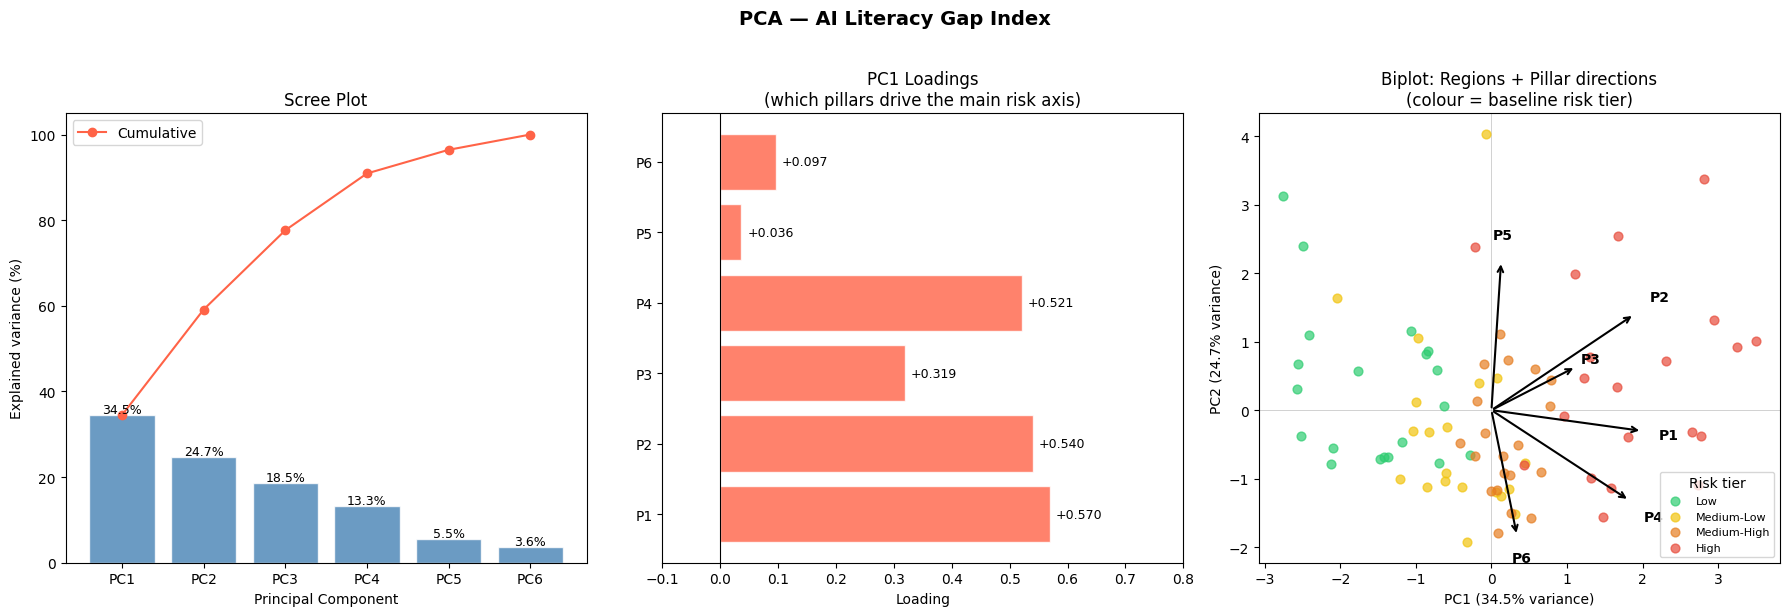

In [192]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('PCA — AI Literacy Gap Index', fontsize=14, fontweight='bold', y=1.02)

pillar_labels = list(PILLARS.keys())
var_ratio = pca.explained_variance_ratio_
loadings = pca.components_

# -----------------------------
# Plot 1: Scree plot
# -----------------------------
axes[0].bar(range(1, 7), var_ratio * 100, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].plot(range(1, 7), np.cumsum(var_ratio) * 100, 'o-', color='tomato', label='Cumulative')
for i, v in enumerate(var_ratio * 100):
    axes[0].text(i + 1, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained variance (%)')
axes[0].set_title('Scree Plot')
axes[0].legend()
axes[0].set_xticks(range(1, 7))
axes[0].set_xticklabels([f'PC{i}' for i in range(1, 7)])

# -----------------------------
# Plot 2: PC1 loadings
# -----------------------------
pc1_load = loadings[0]
bars = axes[1].barh(pillar_labels, pc1_load, color='tomato', alpha=0.8, edgecolor='white')
axes[1].axvline(x=0, color='black', linewidth=0.8)
for bar, val in zip(bars, pc1_load):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                 f'{val:+.3f}', va='center', ha='left', fontsize=9)
axes[1].set_xlabel('Loading')
axes[1].set_title('PC1 Loadings\n(which pillars drive the main risk axis)')
axes[1].set_xlim(-0.1, 0.8)

# -----------------------------
# Plot 3: Biplot — regions in PC1/PC2 space + pillar arrows
# -----------------------------
complete_idx = norm_df[norm_cols].dropna().index
scaled_data = StandardScaler().fit_transform(norm_df.loc[complete_idx, norm_cols])
scores = pca.transform(scaled_data)

baseline_scores = norm_df.loc[complete_idx, norm_cols].mean(axis=1)
q = pd.qcut(baseline_scores, 4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
colors_map = {'Low': '#2ecc71', 'Medium-Low': '#f1c40f', 'Medium-High': '#e67e22', 'High': '#e74c3c'}

ax = axes[2]
for tier, color in colors_map.items():
    mask = q == tier
    ax.scatter(scores[mask, 0], scores[mask, 1], c=color, alpha=0.7, s=40, label=tier, zorder=3)

scale = 3.5
for i, label in enumerate(pillar_labels):
    ax.annotate('', xy=(loadings[0, i] * scale, loadings[1, i] * scale), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    ax.text(loadings[0, i] * scale * 1.18, loadings[1, i] * scale * 1.18,
            label, fontsize=10, fontweight='bold', ha='center', va='center')

ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.set_xlabel(f'PC1 ({var_ratio[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var_ratio[1]*100:.1f}% variance)')
ax.set_title('Biplot: Regions + Pillar directions\n(colour = baseline risk tier)')
ax.legend(title='Risk tier', fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

### What the PCA tells us

**PC1 answers: what differentiates European regions most on AI literacy gap risk?**

> *The largest single difference between regions is a combination of digital skills deficits + poverty + low lifelong learning participation. Regions that score poorly on all three simultaneously are fundamentally different from regions that score well on all three.*

This is not a decision we made — the data revealed it. PC1 is the axis along which regions are most spread apart when all six pillars are considered together.

**What PC1 does not tell us:** whether this is the *only* relevant difference. PC2 (24.7% variance) captures a second independent dimension — driven mainly by P5 (unemployment among low-educated). Some regions differ not in their digital skills profile, but in whether their low-educated population is employed or excluded from the labour market entirely. This is a separate risk mechanism, and it is why P5 remains valuable — especially for clustering.

**Implication for the index:** P1, P2, and P4 load strongly on PC1, confirming they measure the same underlying mechanism. P5 loads near zero on PC1 — not because it is unimportant, but because it captures a *different*, independent dimension of risk.

---

### Why All-PC, not PC1-only

PC1-only weights reflect only 34.5% of the total variance. Concretely: P5 drops from 16.7% (equal weights) to 1.8% — a near-exclusion. This happens not because unemployment is irrelevant, but because P5 varies *differently* from P1/P2/P4. It dominates PC2 (loading: +0.62), which PC1-only completely ignores.

The All-PC approach weights each pillar by its contribution across **all** principal components, weighted by their explained variance share:

$$w_j = \frac{\sum_{k=1}^{6} \lambda_k \cdot |loading_{jk}|}{\sum_j \sum_{k=1}^{6} \lambda_k \cdot |loading_{jk}|}$$

This uses 100% of the variance structure. The result: every pillar lands between 14.8% and 18.4% — close to equal weights, but mathematically derived from the data. This convergence is itself a finding: **each pillar dominates at least one principal component**, confirming that all six dimensions are genuinely needed and no pillar is redundant.

**The equal-weights baseline is therefore not just a convention — it is empirically validated by the All-PC approach.**

---

### Final index decision

**The All-PC PCA weighted score (`pca_all_score`) is the final AI Literacy Gap Index.**

The equal-weights baseline (`index_score`) is retained as a reference to quantify how much the data-driven weighting changes the ranking.

---

## Step 6 — Robustness check: Baseline vs. All-PC PCA

How much does the choice of weighting method actually change the ranking? A high rank correlation between the two variants means the index is robust — the results do not depend heavily on the weighting assumption.

In [193]:
from scipy.stats import spearmanr

# -----------------------------
# Rankings for both variants
# -----------------------------
norm_df['rank_baseline'] = norm_df['index_score'].rank(ascending=False).astype(int)
norm_df['rank_pca']      = norm_df['pca_all_score'].rank(ascending=False).astype(int)
norm_df['rank_diff']     = norm_df['rank_baseline'] - norm_df['rank_pca']

# -----------------------------
# Spearman rank correlation
# -----------------------------
corr, pval = spearmanr(norm_df['rank_baseline'], norm_df['rank_pca'])
print(f'Spearman rank correlation:  r = {corr:.4f}  (p = {pval:.2e})')
print(f'Max rank shift:             {norm_df["rank_diff"].abs().max()} positions')
print(f'Mean rank shift:            {norm_df["rank_diff"].abs().mean():.1f} positions')
print(f'Regions with shift ≥ 5:     {(norm_df["rank_diff"].abs() >= 5).sum()}')
print()

# -----------------------------
# Side-by-side comparison table
# -----------------------------
compare_df = norm_df[['geo', 'rank_baseline', 'rank_pca', 'rank_diff',
                       'index_score', 'pca_all_score']].copy()
compare_df = compare_df.merge(nuts1_lookup, on='geo', how='left')
compare_df = compare_df.rename(columns={
    'index_score':    'baseline_score',
    'rank_diff':      'rank_shift (baseline − pca)',
})
compare_df = compare_df[['rank_pca', 'rank_baseline', 'geo', 'nuts1_name',
                          'pca_all_score', 'baseline_score', 'rank_shift (baseline − pca)']].sort_values('rank_pca').reset_index(drop=True)

display(compare_df.style.hide(axis='index')
    .background_gradient(subset=['rank_shift (baseline − pca)'], cmap='RdYlGn', vmin=-6, vmax=6))

Spearman rank correlation:  r = 0.9977  (p = 5.01e-101)
Max rank shift:             6 positions
Mean rank shift:            1.2 positions
Regions with shift ≥ 5:     2



rank_pca,rank_baseline,geo,nuts1_name,pca_all_score,baseline_score,rank_shift (baseline − pca)
1,1,ITG,Isole,0.730699,0.722121,0
2,2,ITF,Sud,0.699806,0.691378,0
3,3,BG3,Severna i Yugoiztochna Bulgaria,0.651487,0.648244,0
4,4,RO2,Macroregiunea Doi,0.647873,0.639589,0
5,6,FRY,RUP FR — Régions Ultrapériphériques Françaises,0.642841,0.627648,1
6,5,EL6,Kentriki Elláda,0.638653,0.631984,-1
7,7,PT3,Região Autónoma da Madeira,0.613644,0.611472,0
8,8,FRM,Corse,0.600869,0.600876,0
9,10,RO4,Macroregiunea Patru,0.597879,0.589950,1
10,11,RO1,Macroregiunea Unu,0.593816,0.586836,1


### Robustness finding

**Spearman r = 0.9977** — the two variants are nearly perfectly correlated. The maximum rank shift across all 87 regions is 6 positions, with an average of 1.2.

This confirms two things simultaneously:
1. **The All-PC PCA index is robust** — the ranking does not depend on the weighting assumption
2. **The equal-weights baseline is vindicated** — it produces essentially the same result as the data-driven approach, which is itself evidence that equal weights was the right default

The `rank_shift` column is colour-coded: green = region ranks higher under PCA, red = region ranks lower under PCA. No region moves by more than 6 positions.

---

## Step 7 — Save final index

Save the final index to `data/processed/ai_literacy_gap_index.csv`.

The output file contains:
- **`ai_literacy_gap_index`** — final index (All-PC PCA weights, ↑ = higher risk)
- **`baseline_score`** — equal-weights reference
- **`pillars_available`** — number of pillars used (6 = complete, 5 = P5 missing)
- **`P1_norm` – `P6_norm`** — individual normalised pillar scores for downstream clustering

In [194]:
from datetime import date

# -----------------------------
# Assemble final output
# -----------------------------
COUNTRY_NAMES = {
    'AT':'Austria','BE':'Belgium','BG':'Bulgaria','CY':'Cyprus','CZ':'Czechia',
    'DE':'Germany','DK':'Denmark','EE':'Estonia','EL':'Greece','ES':'Spain',
    'FI':'Finland','FR':'France','HR':'Croatia','HU':'Hungary','IE':'Ireland',
    'IT':'Italy','LT':'Lithuania','LU':'Luxembourg','LV':'Latvia','MT':'Malta',
    'NL':'Netherlands','PL':'Poland','PT':'Portugal','RO':'Romania','SE':'Sweden',
    'SI':'Slovenia','SK':'Slovakia',
}
lookup = pd.read_csv(PROCESSED_DIR / 'nuts1_lookup.csv')[['geo', 'nuts1_name', 'country_code']]
lookup['country'] = lookup['country_code'].map(COUNTRY_NAMES)

output = norm_df[['geo', 'index_score', 'pca_all_score', 'pillars_available',
                   'P1_norm', 'P2_norm', 'P3_norm', 'P4_norm', 'P5_norm', 'P6_norm']].copy()
output = output.merge(lookup[['geo', 'country', 'nuts1_name']], on='geo', how='left')
output = output.rename(columns={
    'pca_all_score': 'ai_literacy_gap_index',
    'index_score':   'baseline_score',
})
output['rank'] = output['ai_literacy_gap_index'].rank(ascending=False).astype(int)

cols = ['rank', 'geo', 'country', 'nuts1_name',
        'ai_literacy_gap_index', 'baseline_score', 'pillars_available',
        'P1_norm', 'P2_norm', 'P3_norm', 'P4_norm', 'P5_norm', 'P6_norm']
output = output[cols].sort_values('rank').reset_index(drop=True)

# -----------------------------
# Save to processed/
# -----------------------------
output_path = PROCESSED_DIR / 'ai_literacy_gap_index.csv'
output.to_csv(output_path, index=False)
print(f'Saved:  {output_path}')
print(f'Shape:  {output.shape}')
print(f'Date:   {date.today()}')
print()
display(output.style.hide(axis='index'))

# -----------------------------
# Register in catalog
# -----------------------------
catalog_path = PROCESSED_DIR / 'project_data_catalog.csv'
catalog = pd.read_csv(catalog_path)

new_entry = {
    'dataset_code':  'ai_literacy_gap_index',
    'dataset_name':  'AI Literacy Gap Index — final composite index (All-PC PCA weights)',
    'pillar':        'composite',
    'processed_file':'ai_literacy_gap_index.csv',
    'n_rows':        len(output),
    'n_columns':     len(output.columns),
    'downloaded_at': str(date.today()),
}
catalog = pd.concat([catalog, pd.DataFrame([new_entry])], ignore_index=True)
catalog.to_csv(catalog_path, index=False)
print(f'Registered in catalog: {catalog_path.name}')

Saved:  /Users/joshuakehrer/code/JoshK00/ai-literacy-gap-index/AI-Literacy-Gap-Index/data/processed/ai_literacy_gap_index.csv
Shape:  (87, 13)
Date:   2026-06-01



rank,geo,country,nuts1_name,ai_literacy_gap_index,baseline_score,pillars_available,P1_norm,P2_norm,P3_norm,P4_norm,P5_norm,P6_norm
1,ITG,Italy,Isole,0.730699,0.722121,6,0.650826,0.971131,0.748593,0.856757,0.353801,0.751617
2,ITF,Italy,Sud,0.699806,0.691378,6,0.717114,0.869221,0.677298,0.851351,0.350877,0.682406
3,BG3,Bulgaria,Severna i Yugoiztochna Bulgaria,0.651487,0.648244,6,0.860537,0.717367,0.242026,0.918919,0.336257,0.814360
4,RO2,Romania,Macroregiunea Doi,0.647873,0.639589,6,0.934229,0.743798,0.425891,0.827027,0.441520,0.465071
5,FRY,France,RUP FR — Régions Ultrapériphériques Françaises,0.642841,0.627648,6,0.605372,1.000000,0.572233,0.816216,0.587719,0.184347
6,EL6,Greece,Kentriki Elláda,0.638653,0.631984,6,0.733299,0.667978,0.405253,0.989189,0.157895,0.838292
7,PT3,Portugal,Região Autónoma da Madeira,0.613644,0.611472,5,0.629132,0.317246,0.849906,0.721622,nan,0.539457
8,FRM,France,Corse,0.600869,0.600876,5,0.307335,0.582315,0.358349,0.929730,nan,0.826649
9,RO4,Romania,Macroregiunea Patru,0.597879,0.589950,6,1.000000,0.578956,0.257036,0.913514,0.233918,0.556274
10,RO1,Romania,Macroregiunea Unu,0.593816,0.586836,6,0.952135,0.493591,0.320826,0.883784,0.438596,0.432083


Registered in catalog: project_data_catalog.csv
